# Emergency Room

Everyone is enjoying the summer, Covid19 restrictions have been lifted, we all get back to regular exercise and outdoor activities. But once in a while, the inevitable happens: An ill-considered step, a brief second of inattention, and injuries all of all types will happen, that require immediate treatment. Luckily our city hosts a modern hospital with an efficient emergency room where the wounded are being taken care of.

The simulation of hospital environment is a very popular. See [Günal 2010](https://www.tandfonline.com/doi/abs/10.1057/jos.2009.25?journalCode=tjsm20) for an excellent review.

To save more lives, the mayor has asked us to review and potentially improve process efficiency in the ER. To do so, we need to realize the following steps

1. Understand the current process and model is as simulation
2. Formulate key objectives to be optimized
2. Assess process statistics and metrics, to unravel potential improvements to help more patients.
3. Explore more optimized decision policies to increase

So let's dive right into it without further ado.

## Process Model


Patients are classified two-fold
1. By **Severity**. The ER is using the well known [Emergency Severity Index](https://en.wikipedia.org/wiki/Emergency_Severity_Index) to triage patients based on the acuity of patients' health care problems, and the number of resources their care is anticipated to require.
2. **Type of injury** which are defined [here](https://medlineplus.gov/woundsandinjuries.html)

Resources

* Surgery **rooms** that must be
  equipped by considering the type (i.e., the family) of surgery to
  be performed. It will take time to prepare a room for a certain type of injury. These setup times are listed in an excel sheet.
* **Doctors** that are qualified for a subset of all possible injuries

Process dynamics

* **PD-A** Depending on the severity, patients might die if not being treated. Also, if not being treated their severity will increase rather quickly
* **PD-B** The more busy the waiting room is, the less efficient surgeries tend to be. This is because of stress (over-allocation of supporting personal and material). It is phenomenon that is often observed complex queuing processes such as manufacturing or customer services.
* **PD-C** Depending on the severity, patients will die during surgery
* **PD-D** The surgery time correlates with the severity of the injury
* **PD-E** During nights fewer new patients arrive compared to the day

Clearly, more resources are required in the ER and many supported processes are required to run it. However, we leave these out here, as they are not considered to have a major impact on the overall process efficiency. Choosing a correct level of abstraction with a focus on key actors and resources, is the first _key to success_ when optimizing a complex process.


## Key Objectives & Observations

There are two competing processes. First, patient status will detoriate if not treated in time. Eventually, patients will pass away. The treatment process, counters and stops this first process. It must be maximized to minimize loss of life, minimize treatment efforts, while also maximizing treatment efficiency.

The head nurse, who is governing the process based on her long-term experience, is scheduling patients based on the following principle
 > Most urgent injuries first

[comment]: <> (   https://www.merriam-webster.com/dictionary/first%20come%2C%20first%20served)

Clearly if possible it would be great to also
* Minimize waiting times
* Reduce number of surgery room setups

## Analysis

Because of the great variety rooms, we observe a lot of setup steps to prepare surgery rooms. Often even if patients with the same type of injury all already waiting.

## Process Optimization

The idea for model above was orginally formulated by [Kramer et al. in 2019](todo reference) :
> Other relevant applications arise in the context of health-care, where, for example, patients have to be assigned to surgery rooms that must be  equipped by considering the type (i.e., the family) of surgery to be performed. In such cases, the weight usually models a level of urgency for the patient.


## Implementation

The tick-unit of the simulation is hours.

In [3]:
@file:Repository("*mavenLocal")
//@file:DependsOn("com.github.holgerbrandl:kalasim:0.6.97-SNAPSHOT")

//todo use artifact for release
//@file:DependsOn("com.github.holgerbrandl:kalasim:0.6.92")
//@file:DependsOn("com.github.holgerbrandl:kravis:0.8.1")
//@file:DependsOn("org.jetbrains.kotlinx:kotlinx-coroutines-core:1.5.2")

In [4]:
import org.kalasim.examples.er.*
import org.kalasim.*
import org.kalasim.monitors.MetricTimeline
import kotlin.math.pow
import kotlin.math.sqrt
import kotlin.random.Random
import org.kalasim.plot.kravis.display
import org.koin.core.qualifier.named


import org.kalasim.examples.er.*

kravis.SessionPrefs.OUTPUT_DEVICE = kravis.device.JupyterDevice() // bug in library,



## Simulation

Let's start by creating the model.

In [5]:
val er = EmergencyRoom(
    numPhysicians = 8,
    patientArrival = exponential(0.25.hours),
)

// enable log to capture events for later analysis
er.enableEventLog()


org.kalasim.EventLog@9d469

Now run it for some days, and print its state afterwards

In [6]:
er.run(7.days)

// print the object to render short status summary
er

EmergencyRoom Summary Statistics (at t=2022-03-02T06:00:00Z):
  Physicians: 8
  Rooms: 4
  Waiting Area Capacity: 300
  
  Incoming Patients: 344
  Currently Waiting: 12
  Treated Successfully: 291
  Deceased: 37
  Success Rate: 88,72%
  
  Nurse Policy: FifoNurse

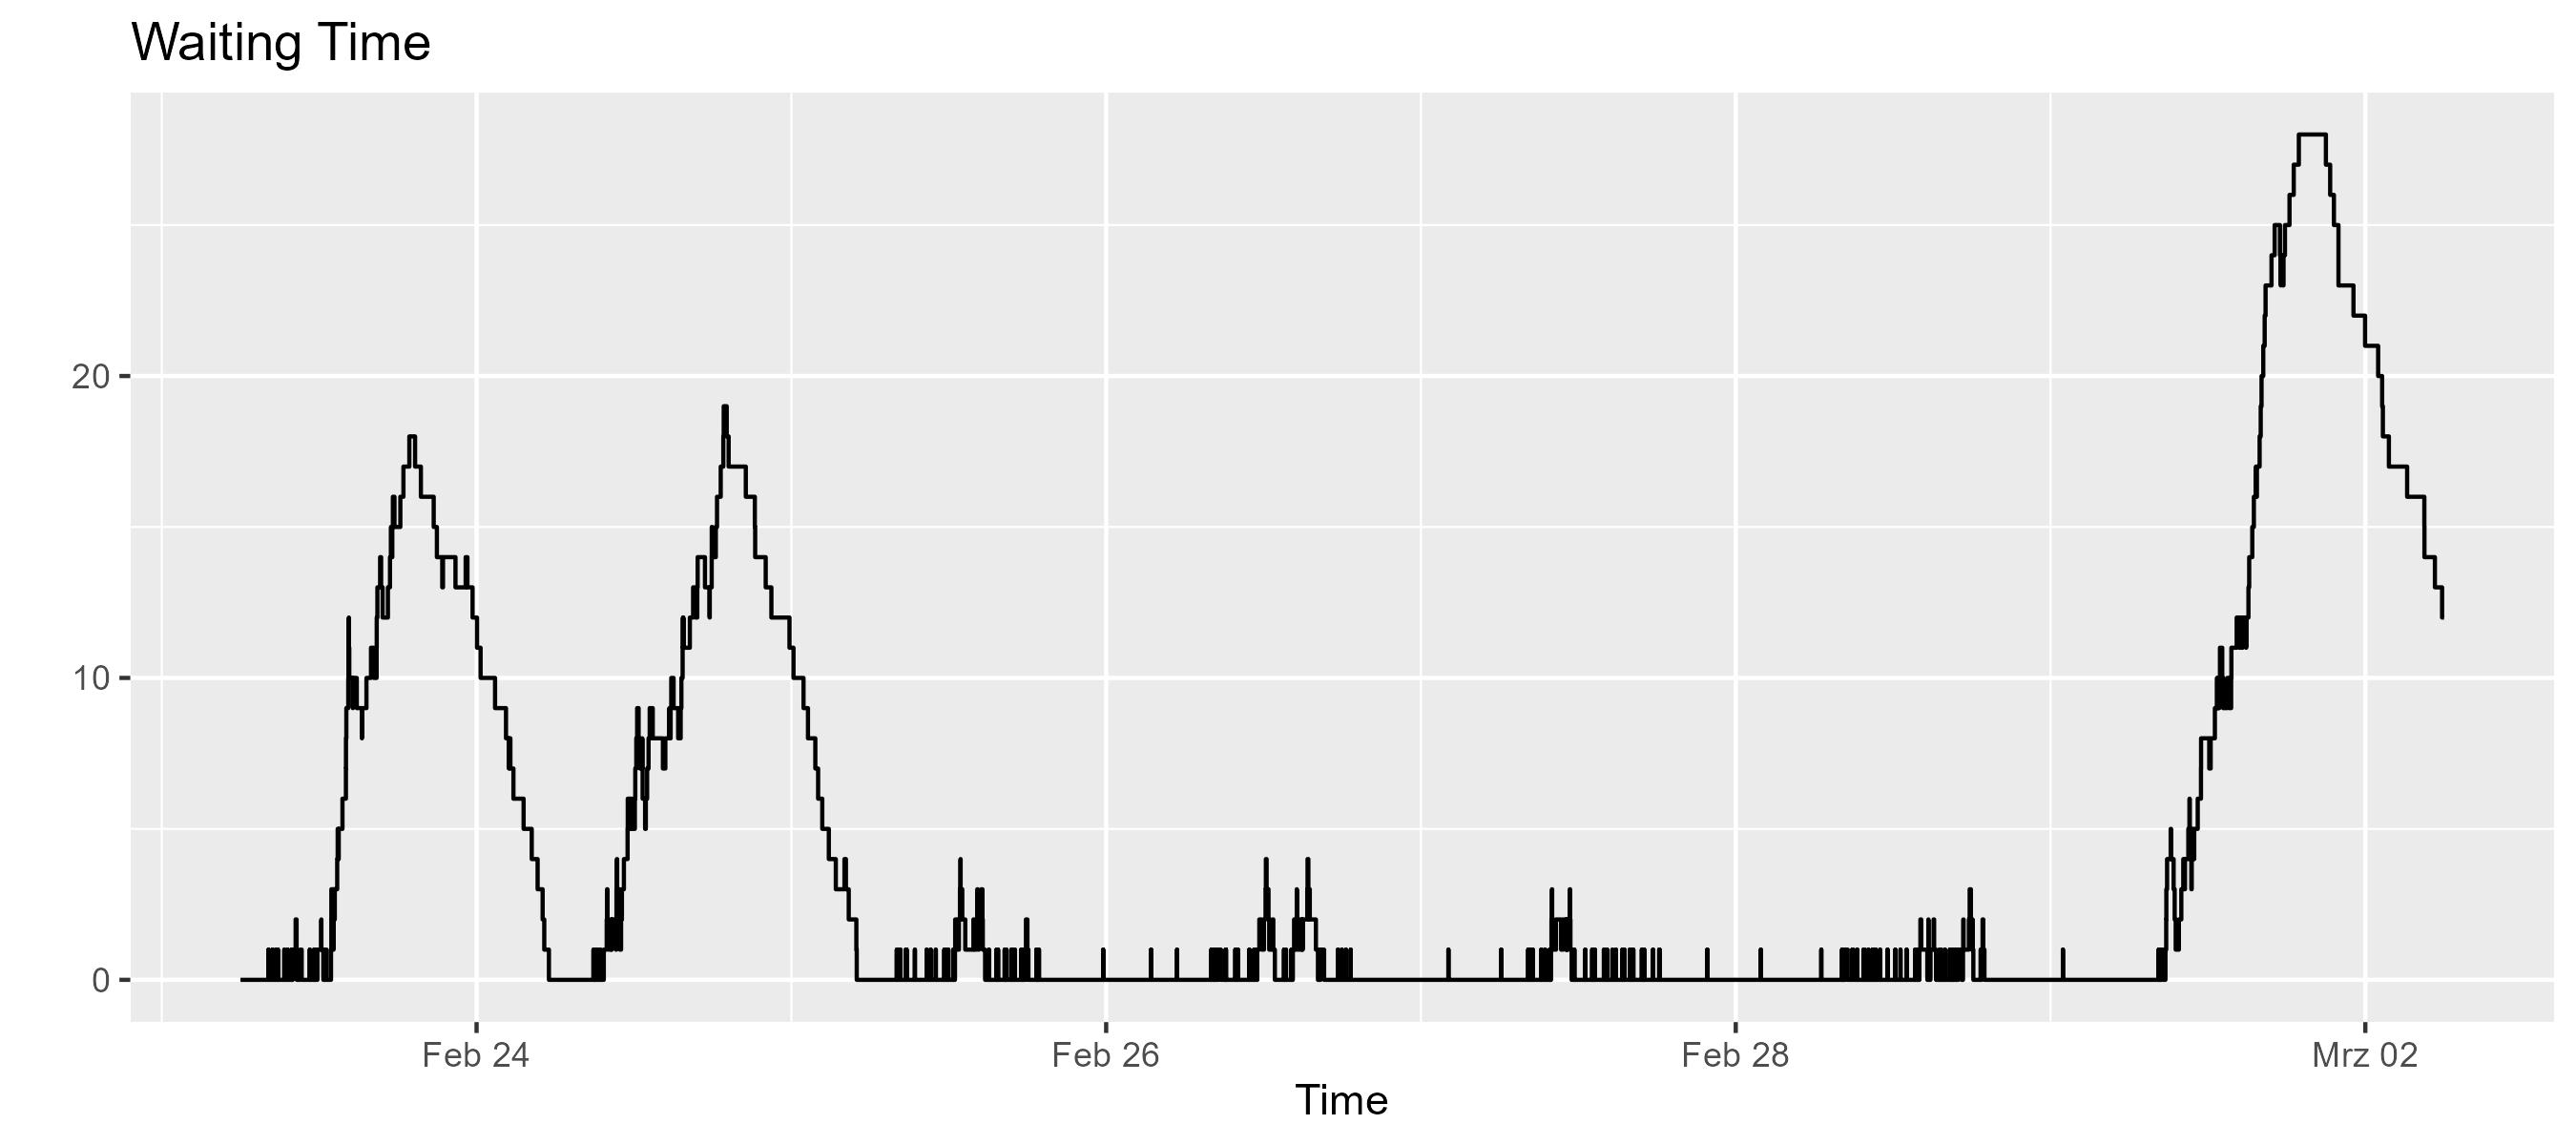

In [7]:
er.waitingLine.sizeTimeline.display("Waiting Time")

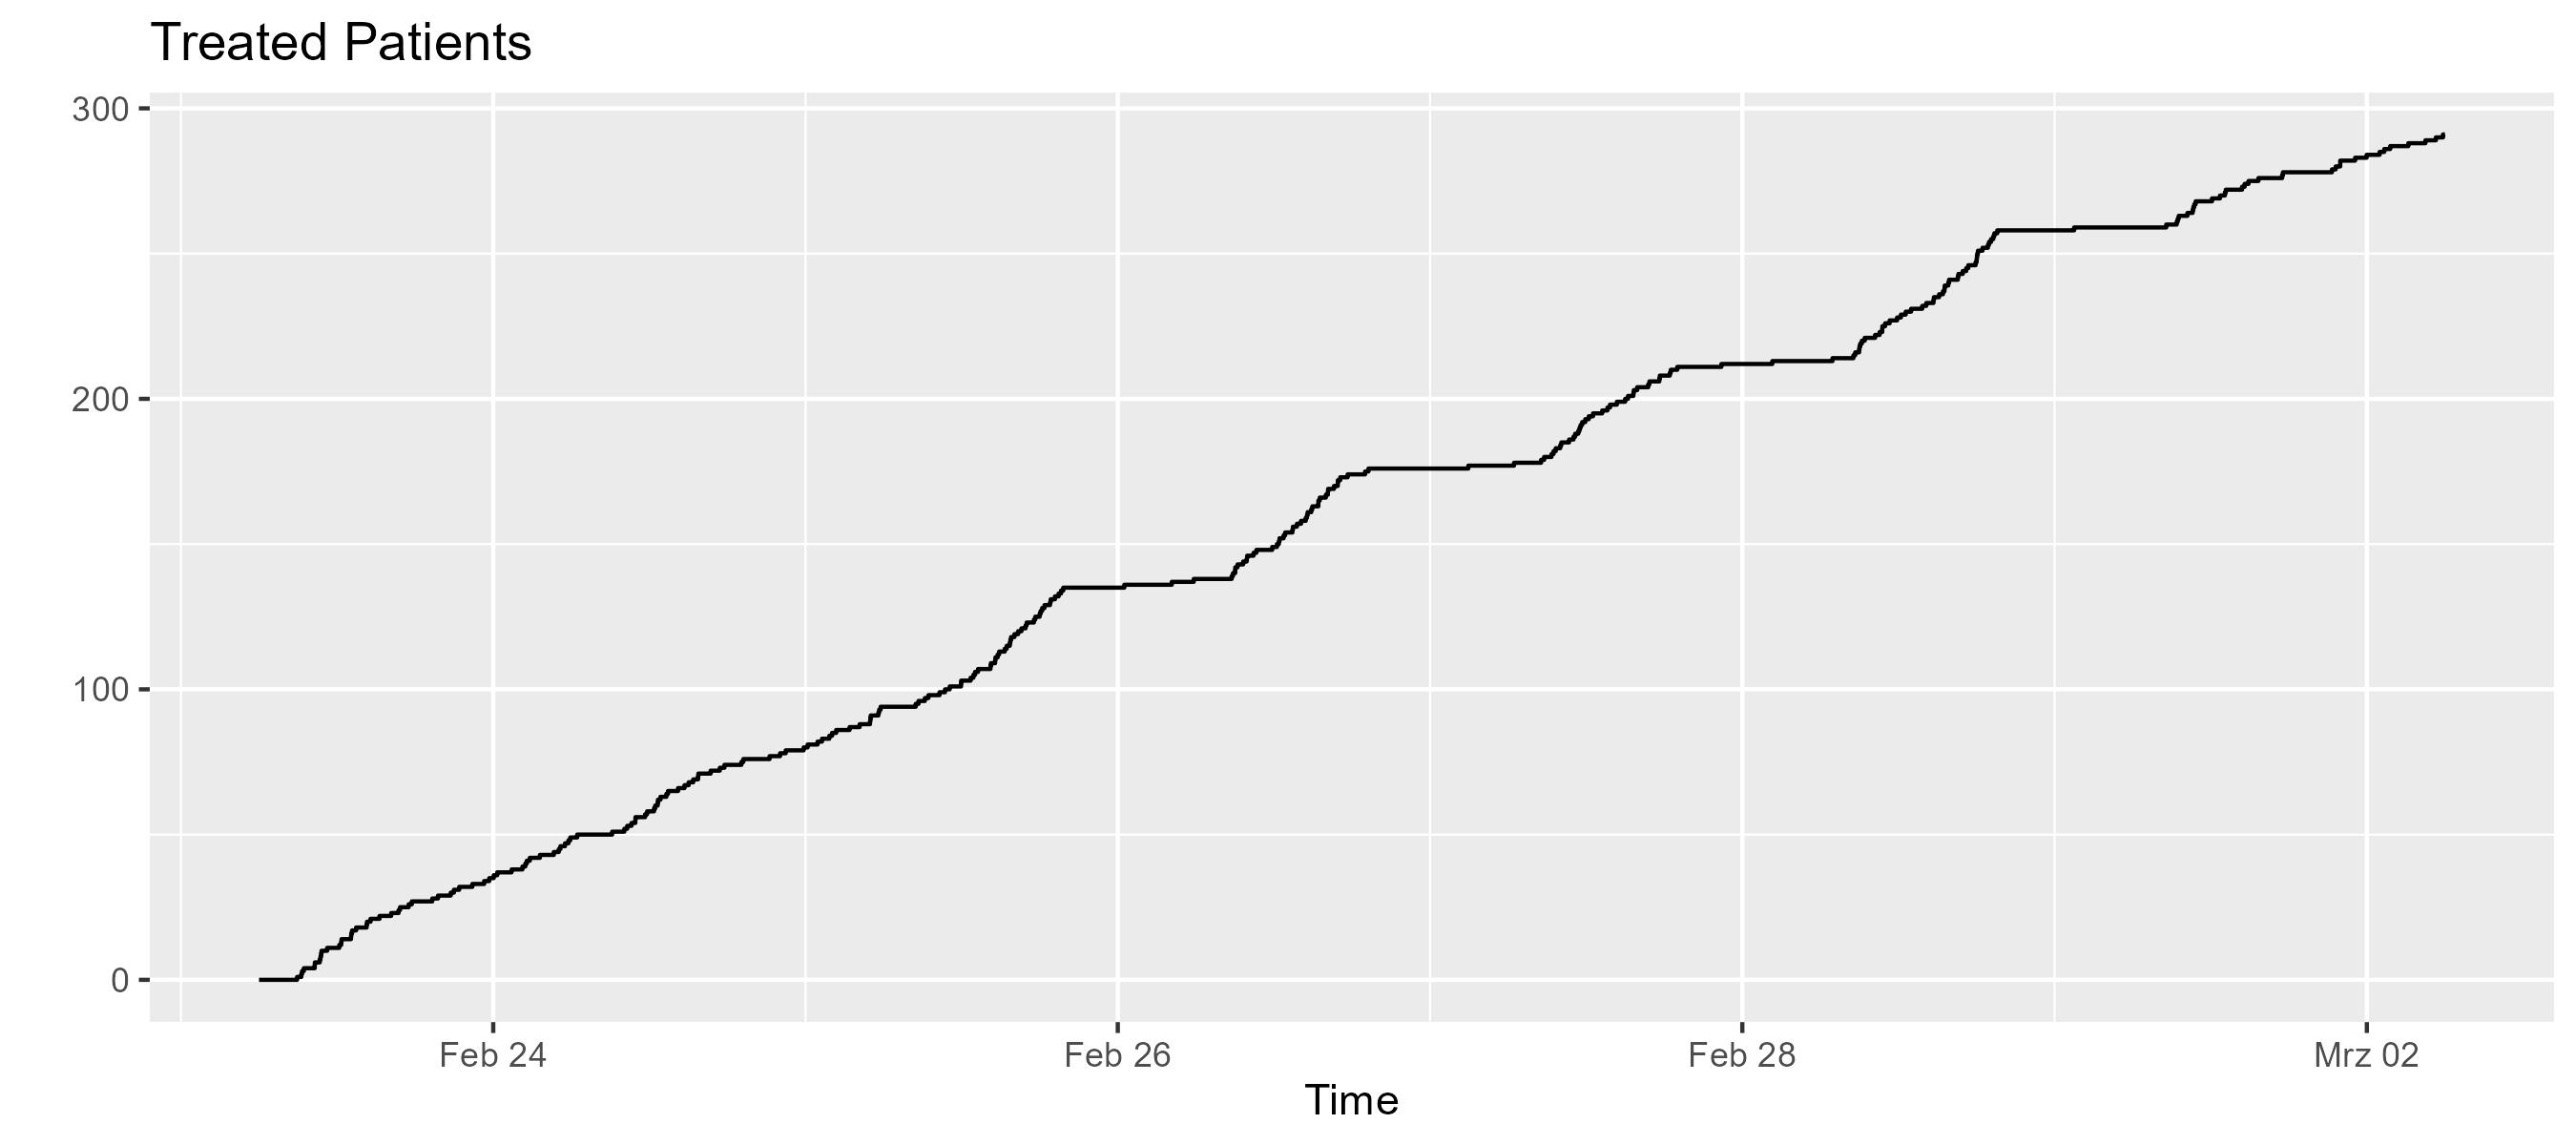

In [8]:
er.treatedMonitor.display("Treated Patients")

Thats visualization is technically correct, but most likely we rather want to see treated patients per day


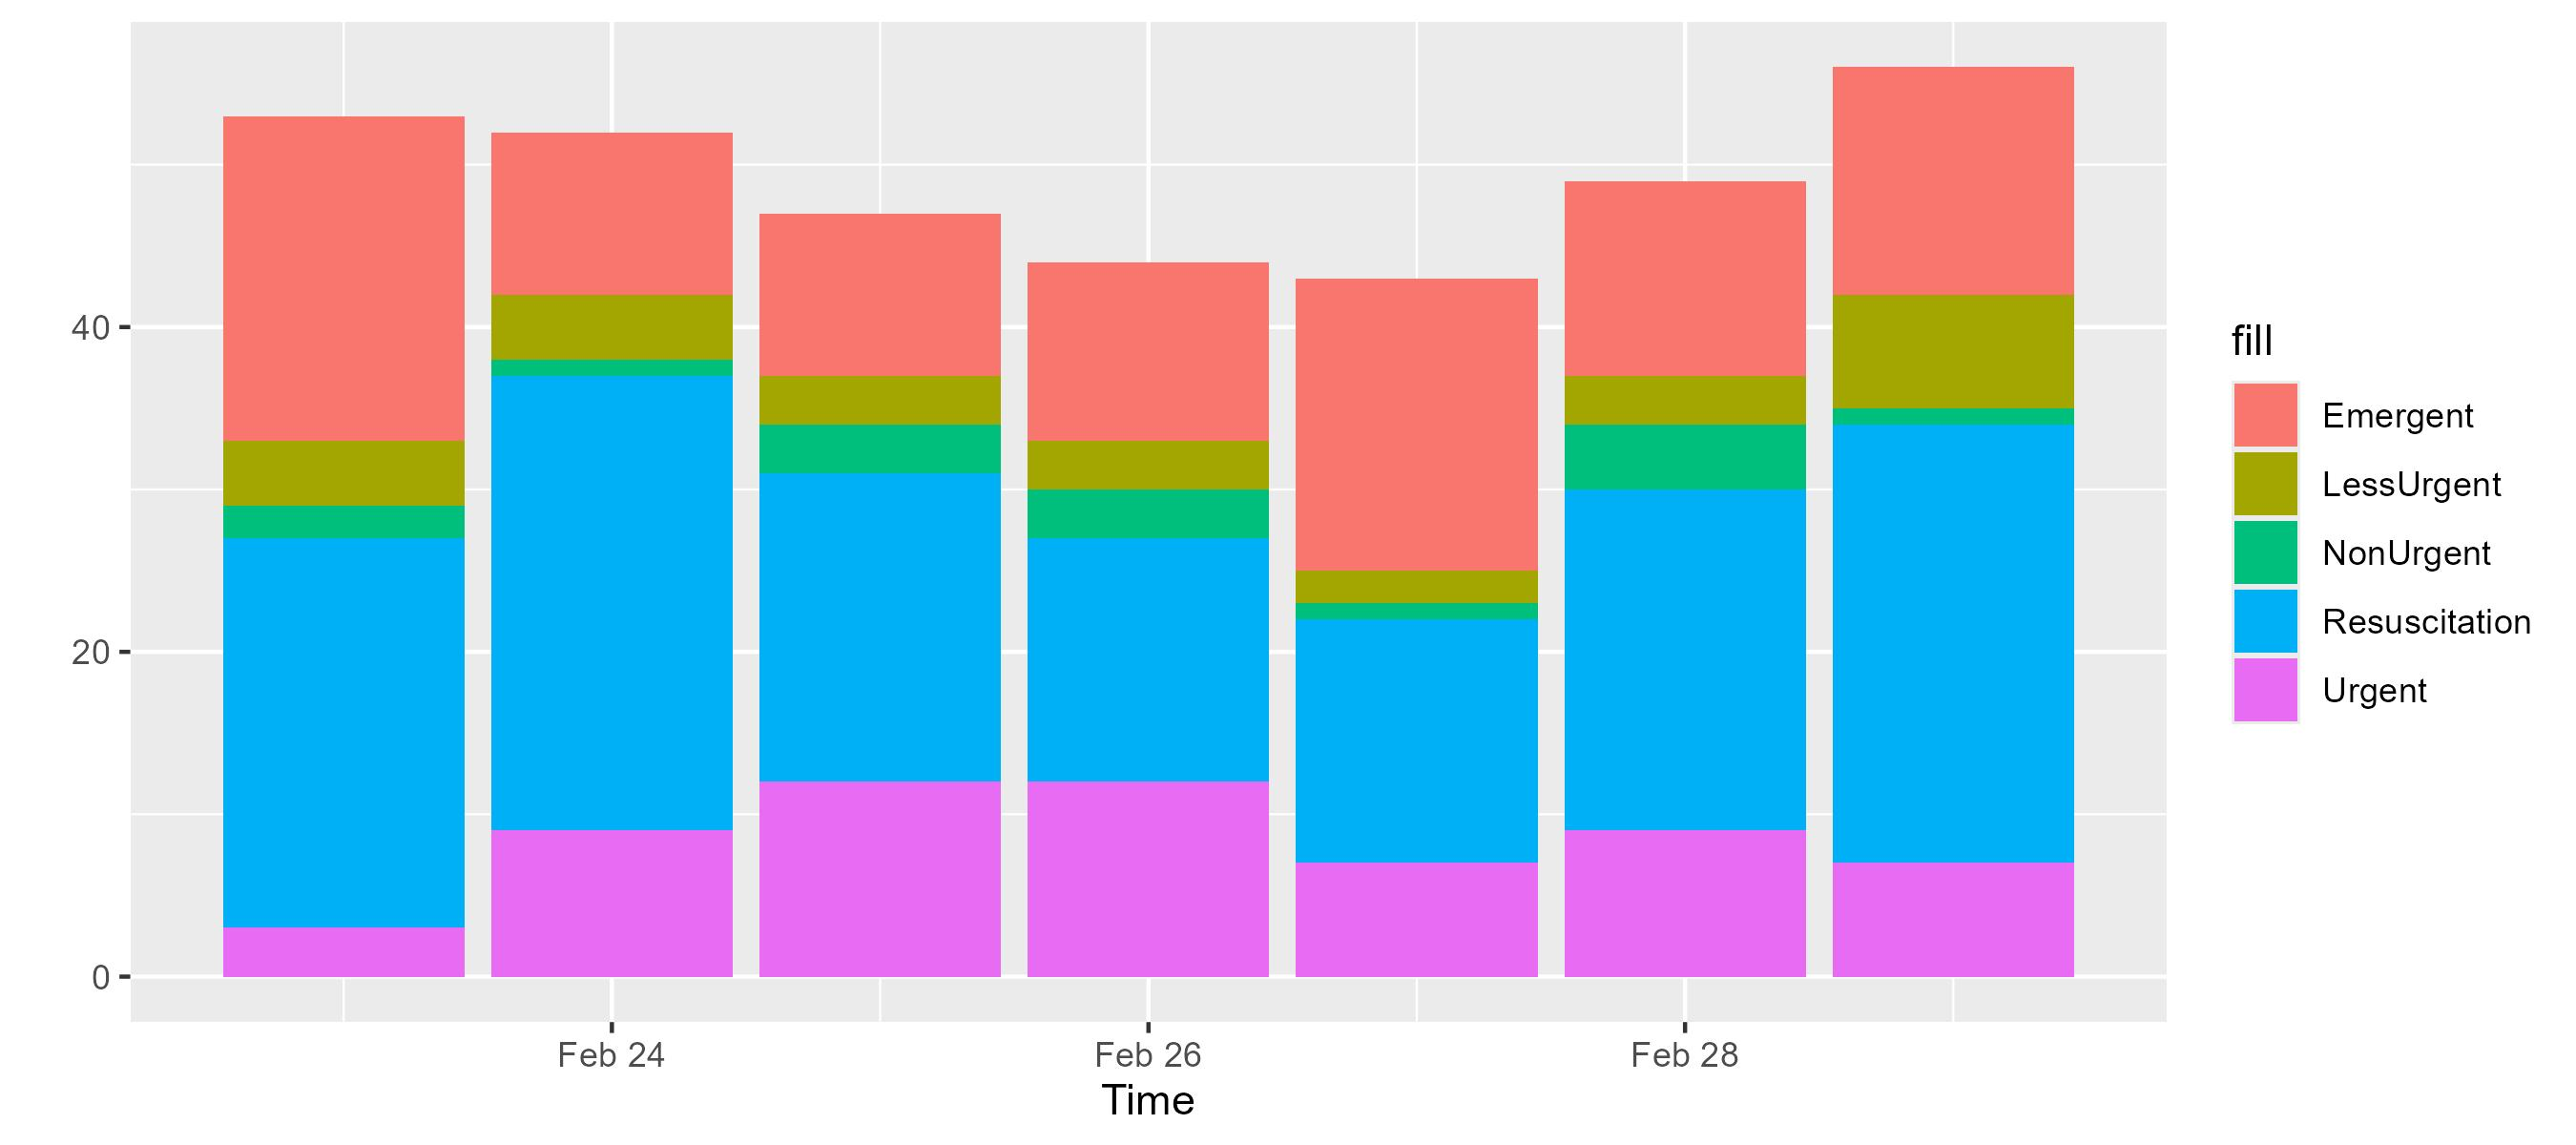

In [9]:
import org.kalasim.plot.kravis.displayStateCounts

er.patients.map{it.severity}.displayStateCounts()

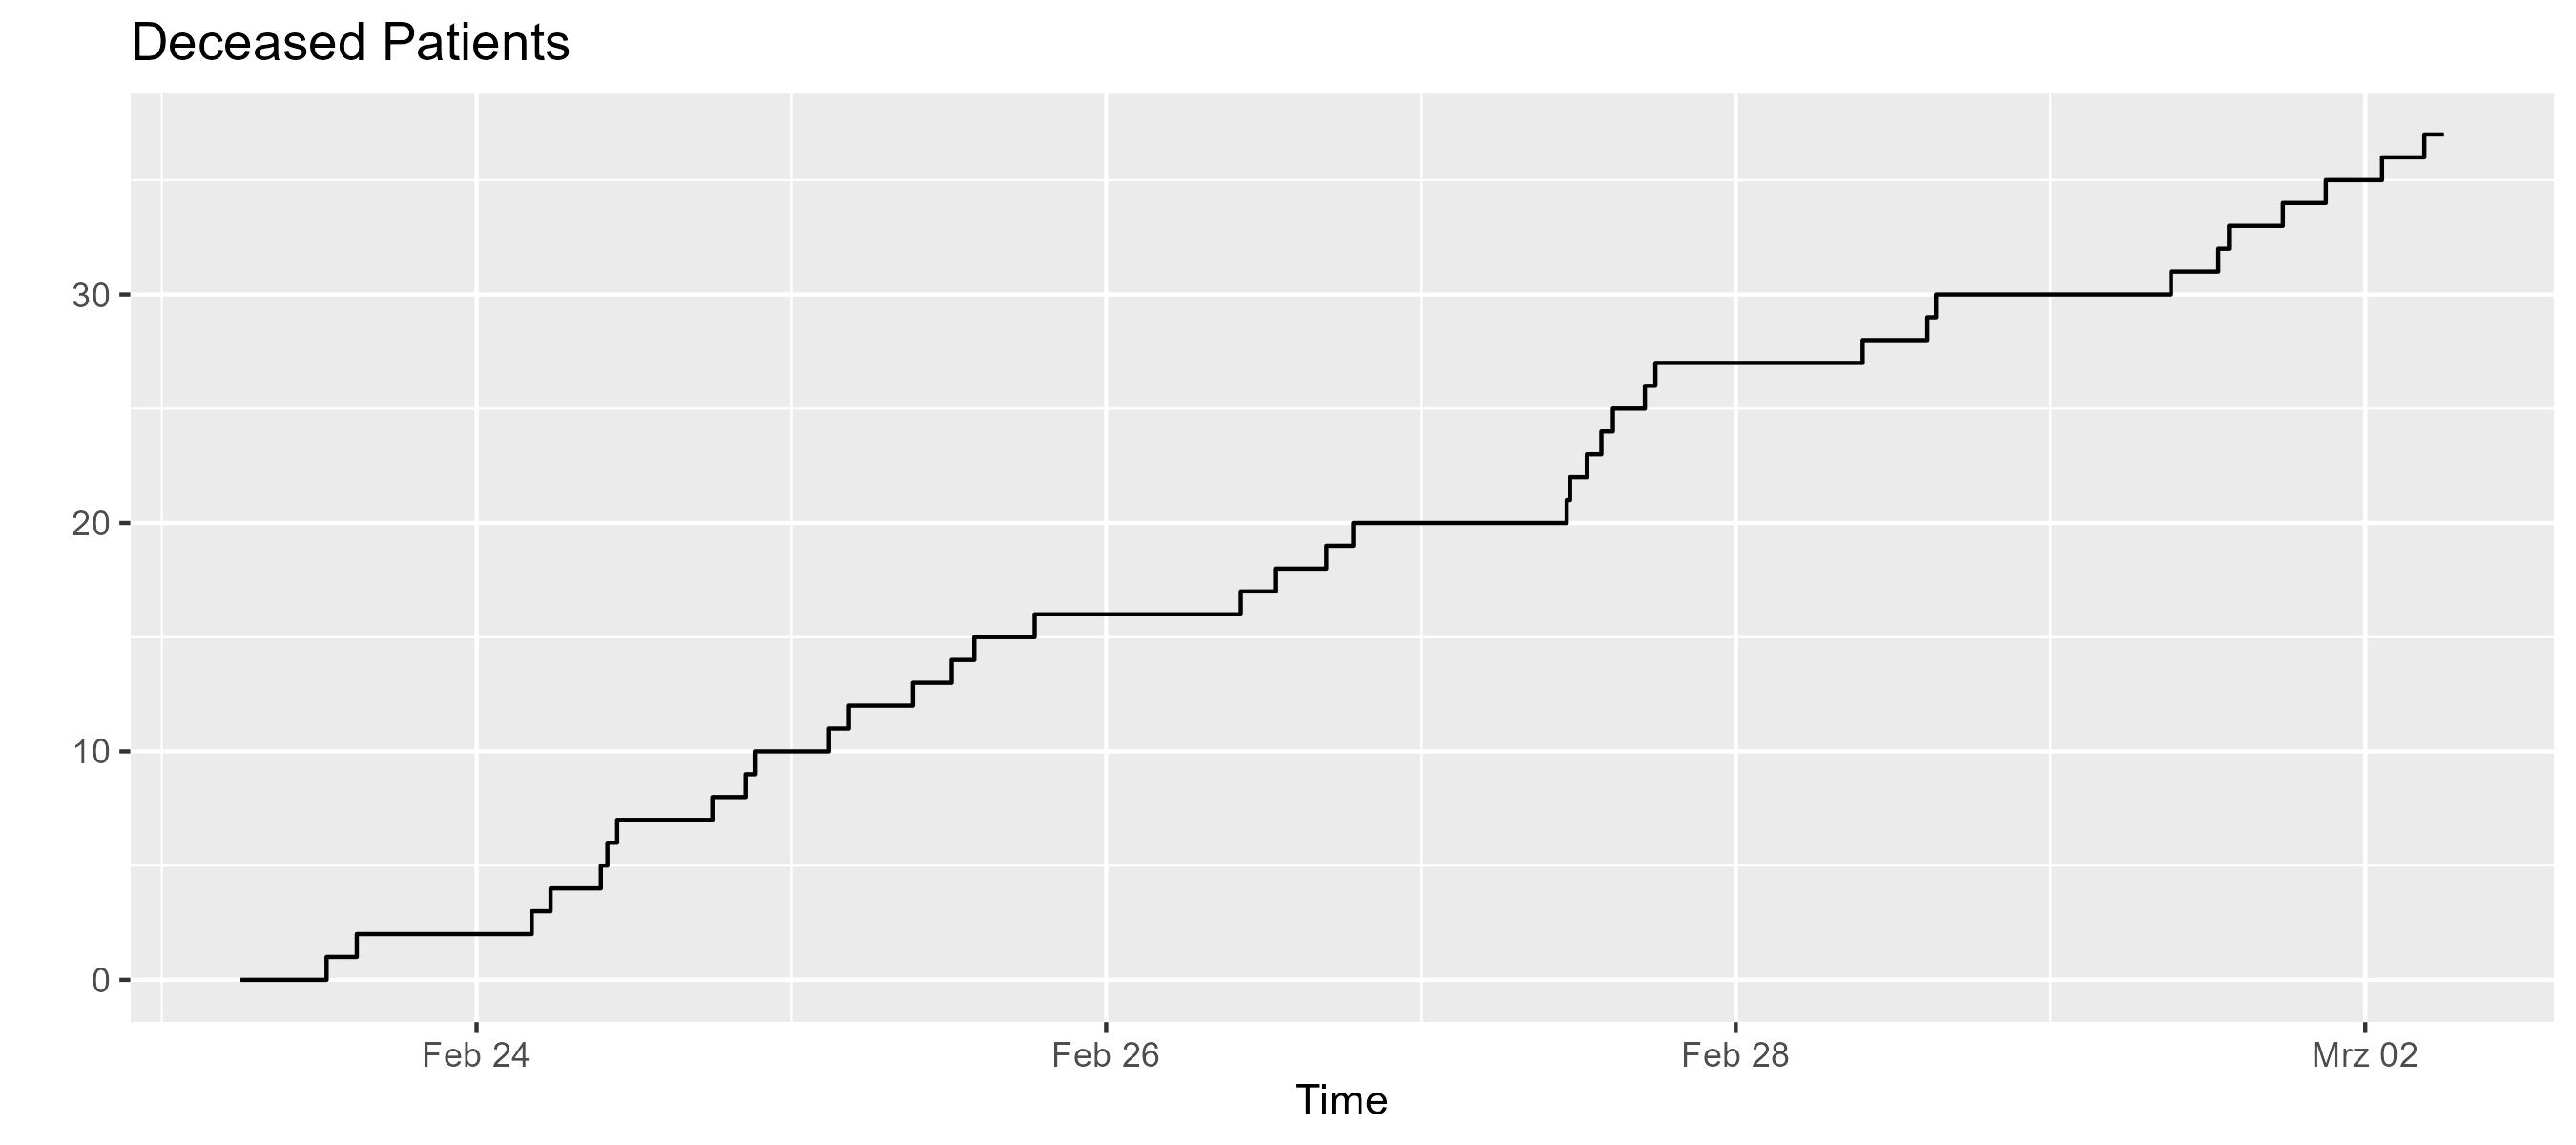

In [10]:
 er.deceasedMonitor.display("Deceased Patients")

## Analysis

To analyze the model, we first use different visualization functinos defined for collection os [states](https://www.kalasim.org/state/), [components](https://www.kalasim.org/component/) and [resources](https://www.kalasim.org/resource/).

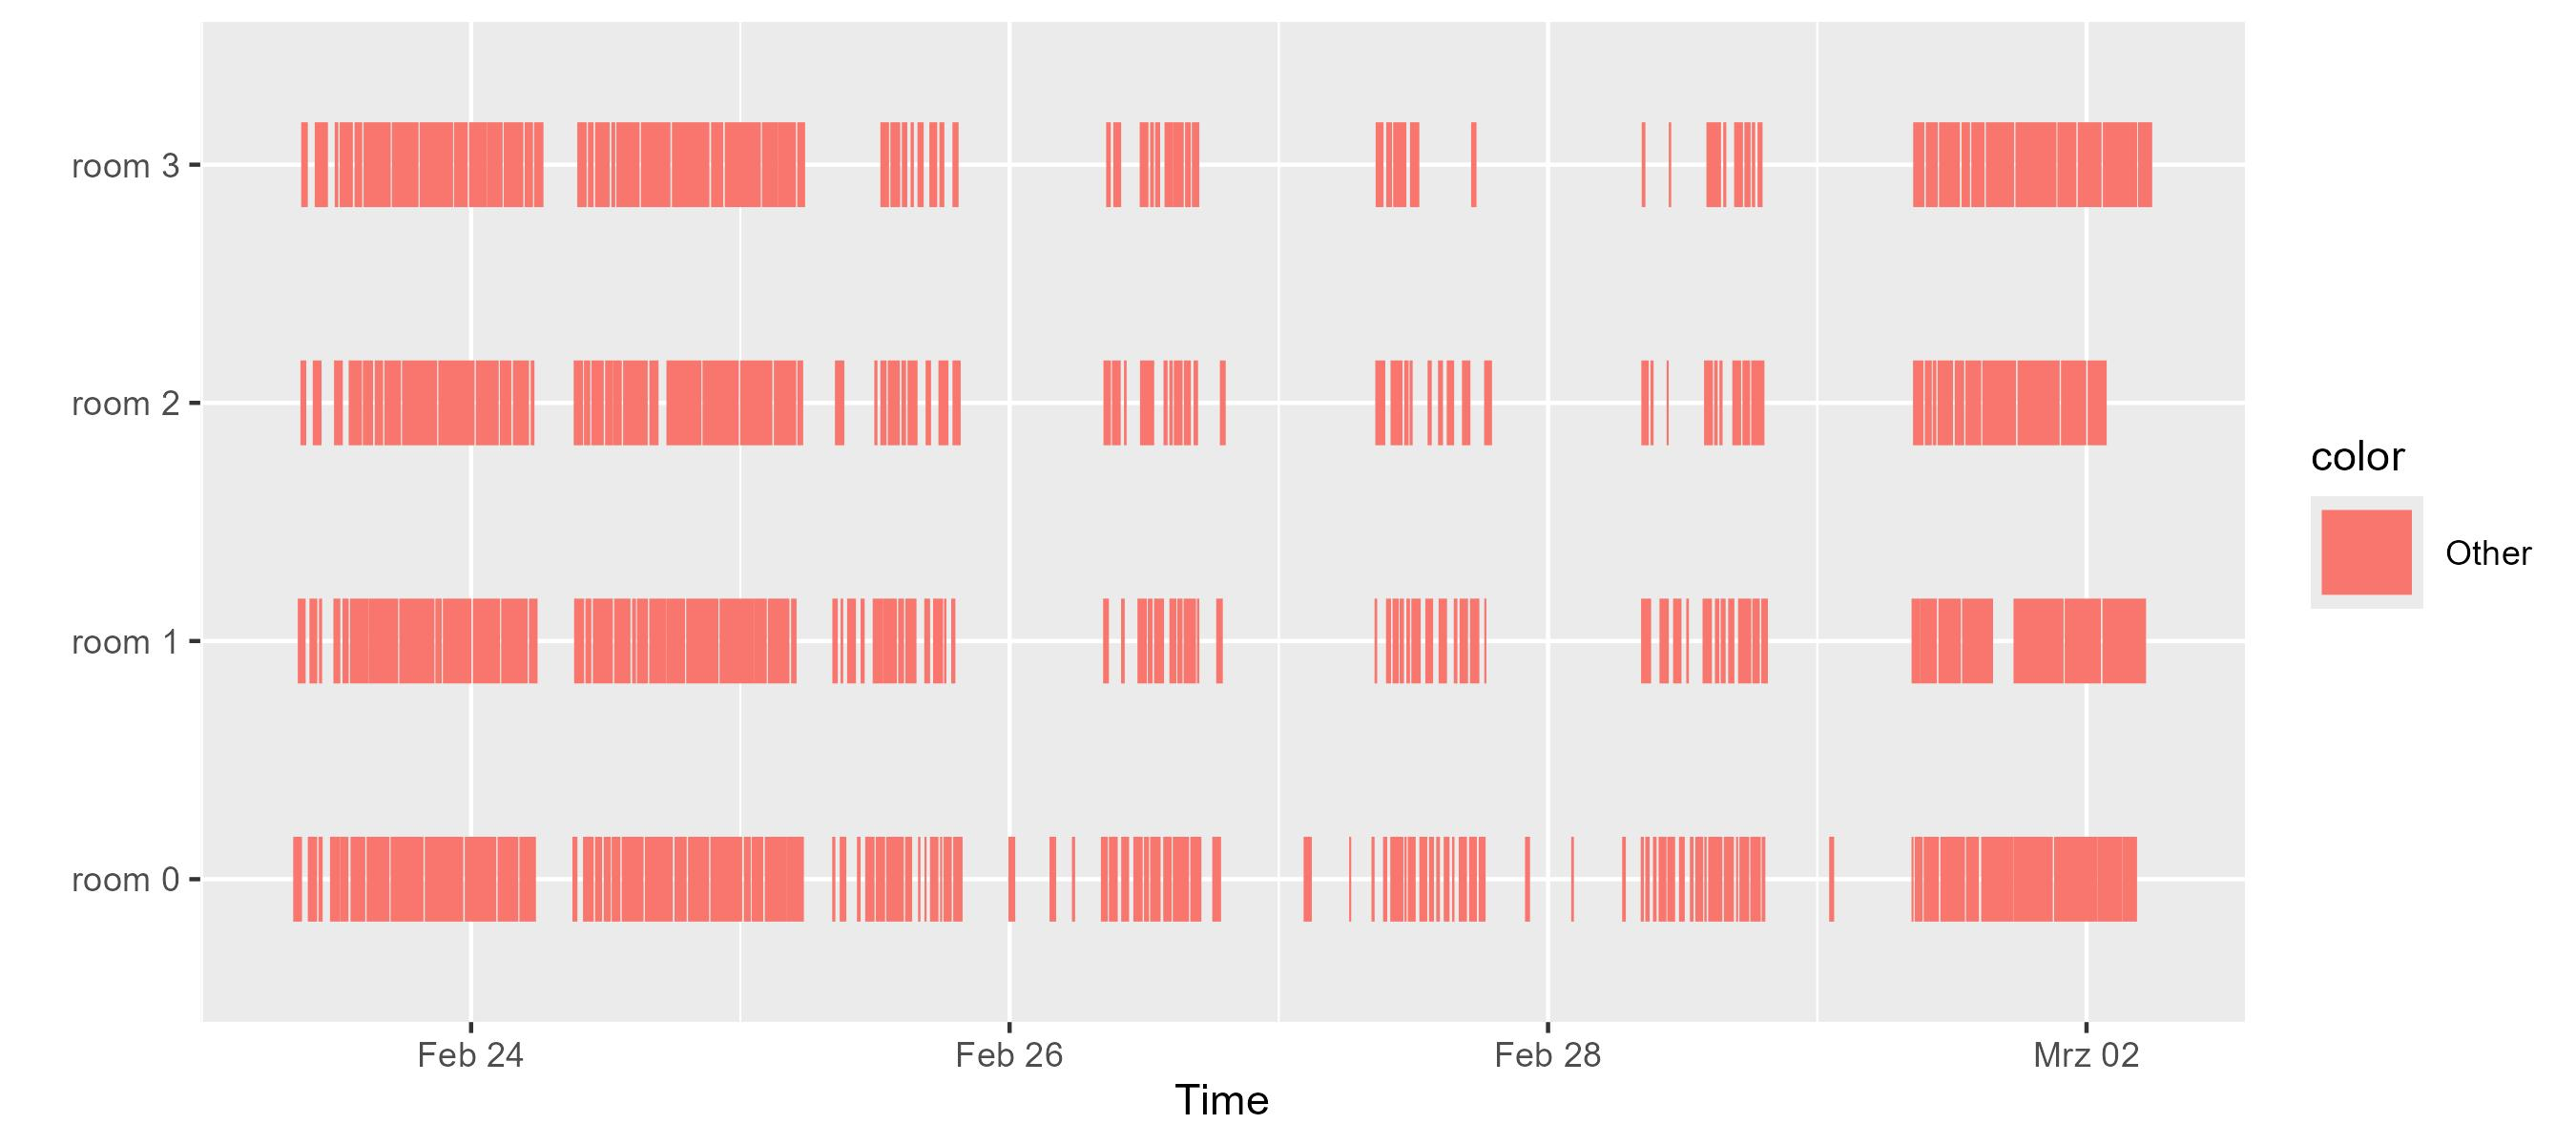

In [12]:
import org.kalasim.plot.kravis.displayTimelines

er.doctors.displayTimelines()


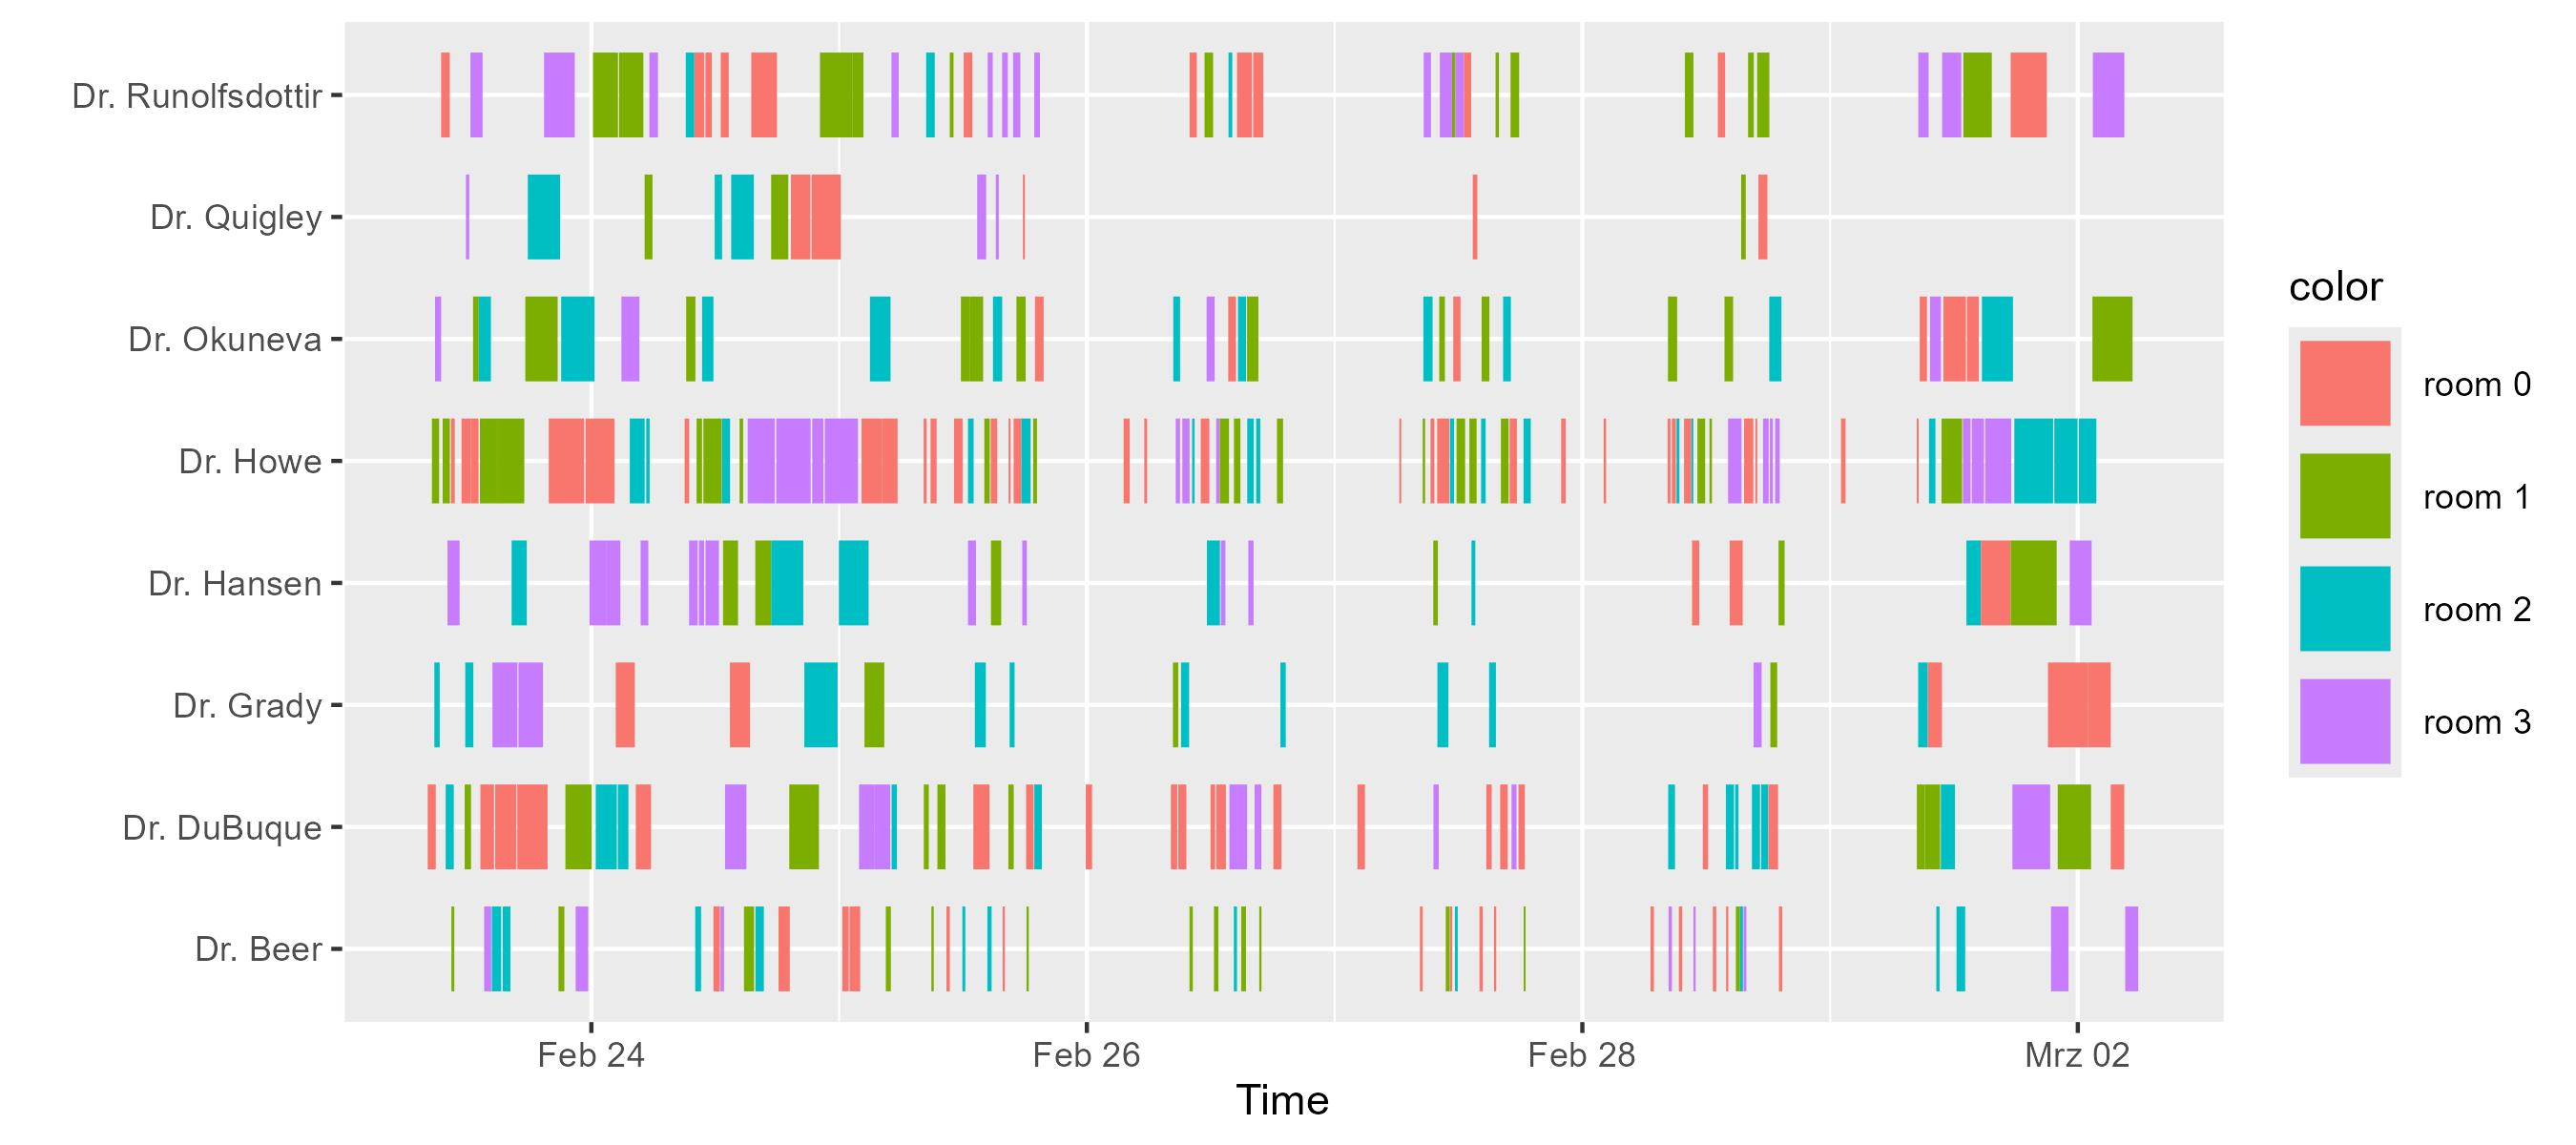

In [13]:
er.doctors.displayTimelines(byRequester = true, colorBy = { it.requester.name})

When studying the data from above, we observe that  an ER with more staff than available surgery rooms (e.g., `numPhysicians = 8` but only a limited number of rooms as defined in the `EmergencyRoom` example), we observe that the bottleneck shifts from staff availability to room availability.


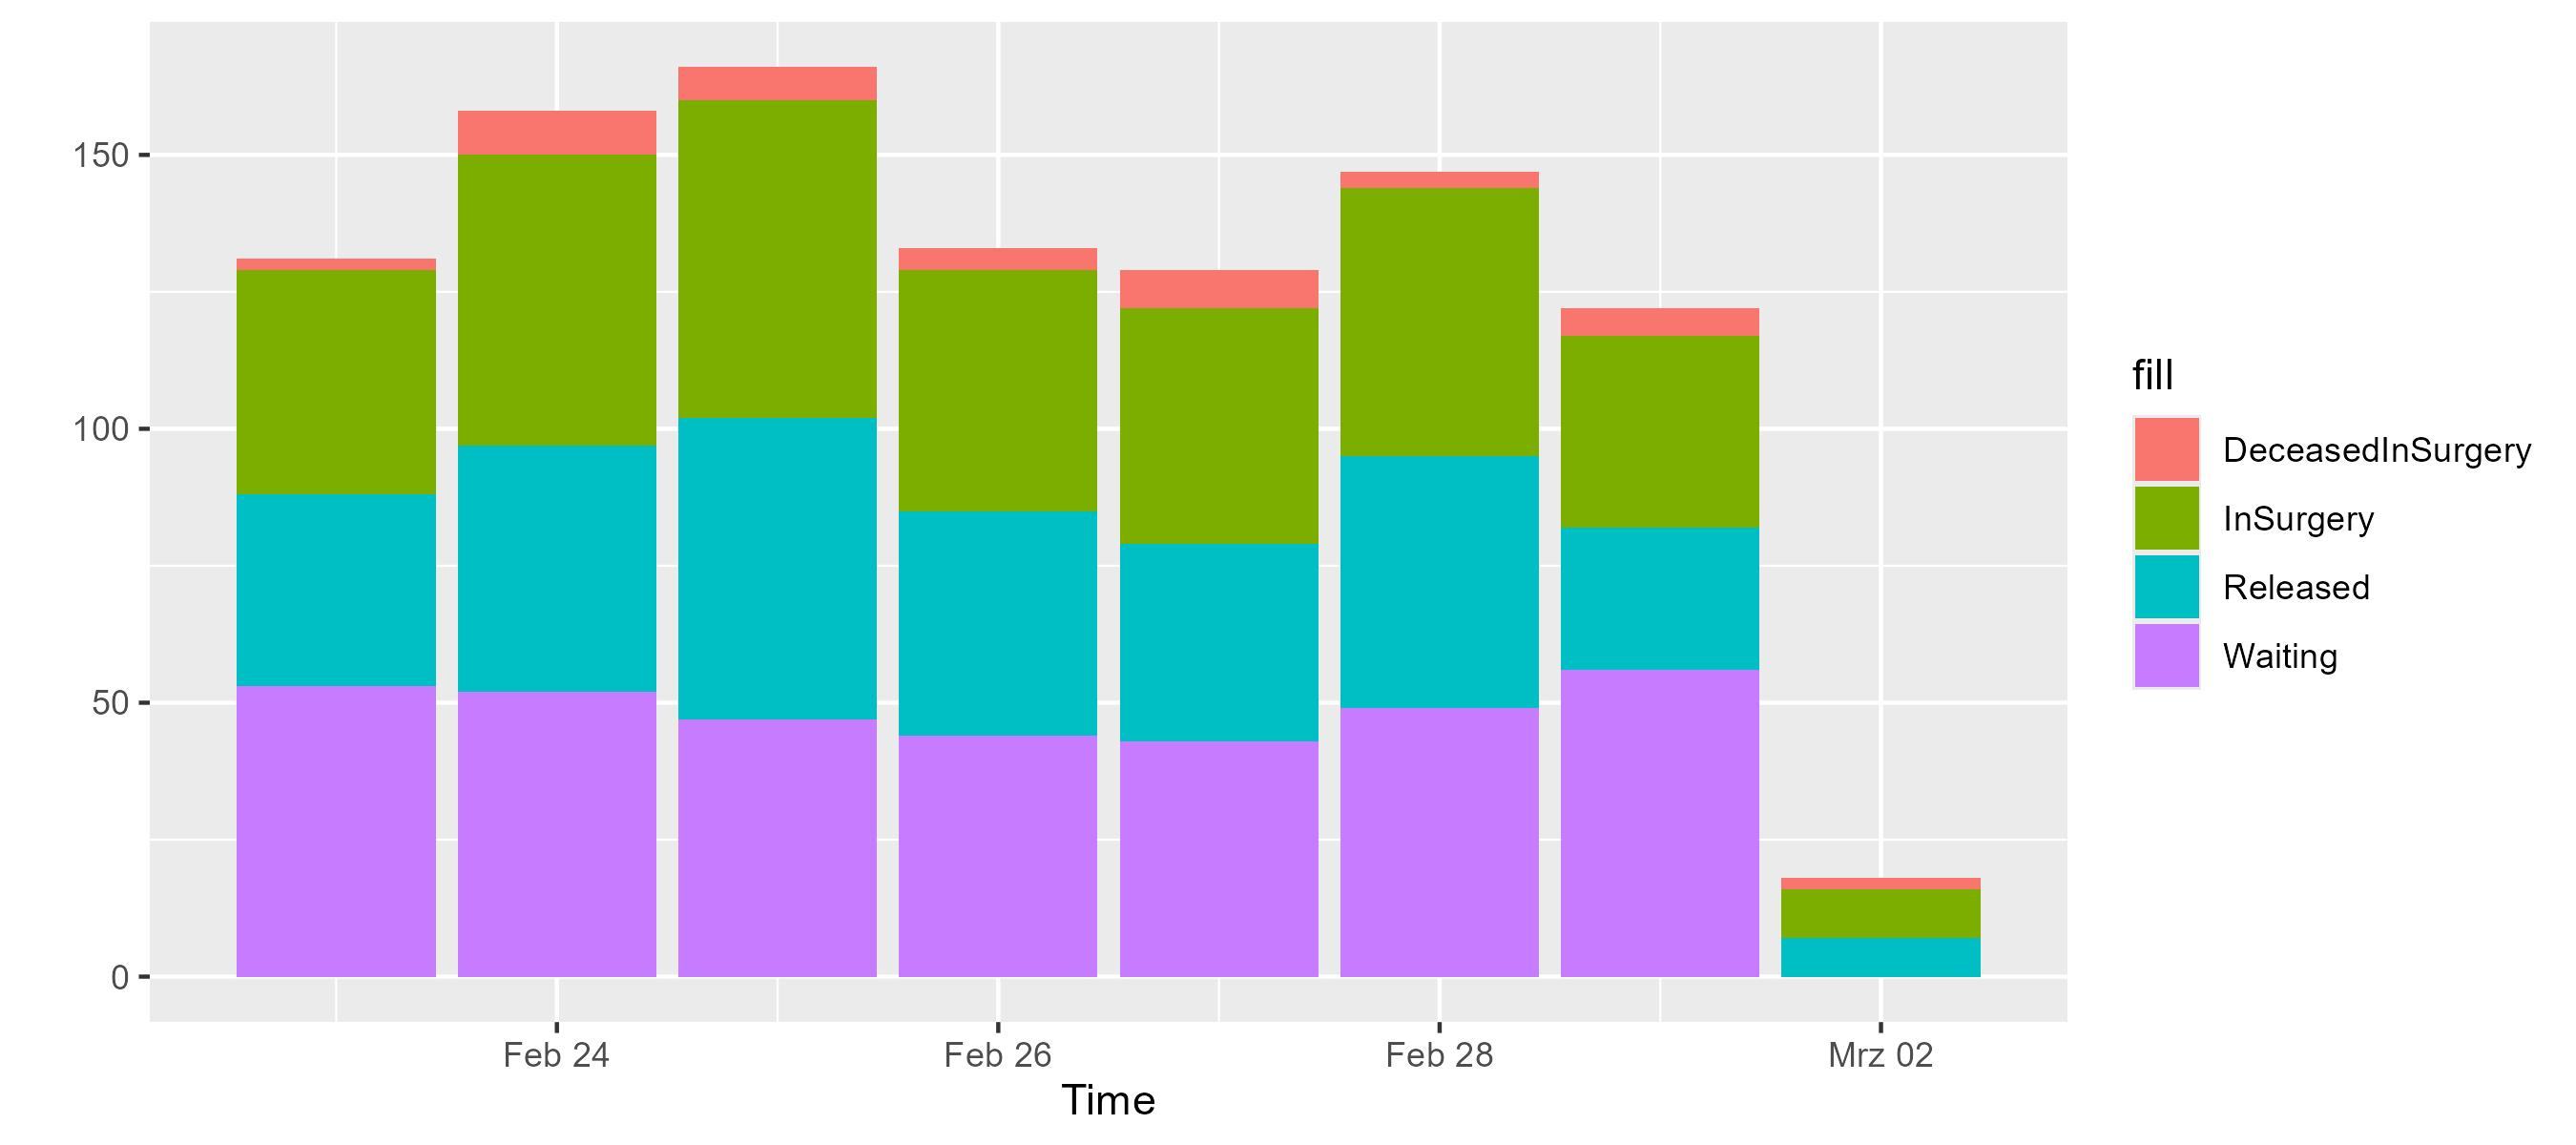

In [14]:
import org.kalasim.plot.kravis.displayStateCounts

er.patients.map { it.patientStatus }.displayStateCounts()


Daily statistics vary slightly, but the overall distribution remains stable. This is expected since the current model does not yet include time-varying factors such as weekend shifts or staff changes.


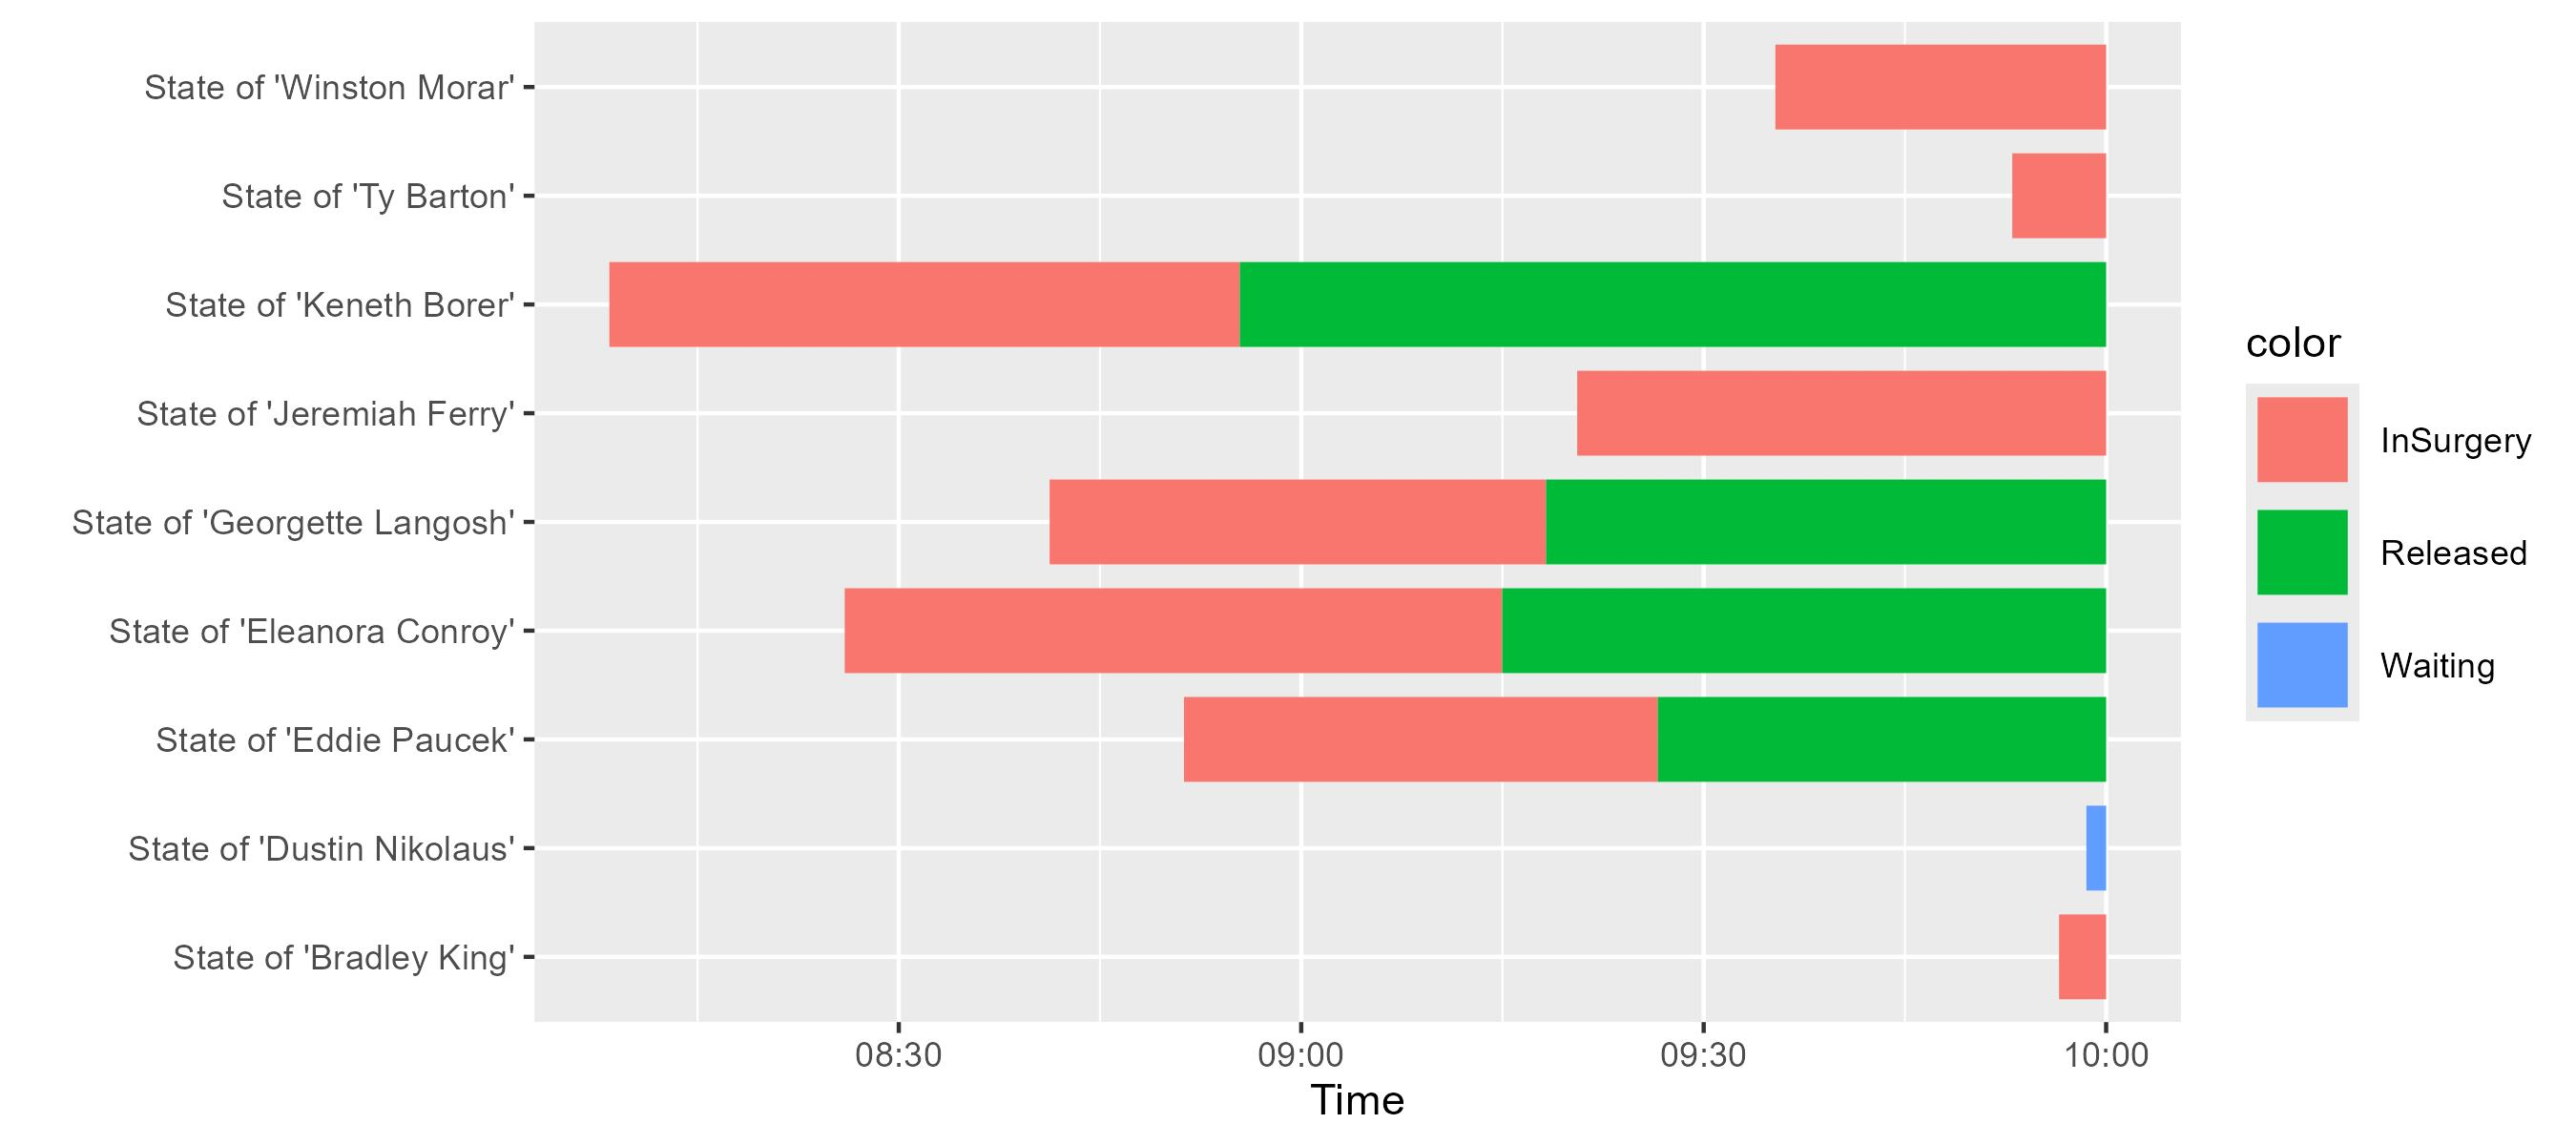

In [17]:
er.patients.take(20).map { it.patientStatus }.displayTimelines(to = er.startDate + 4.hours)


We observe the different arrivals and their stay durations. Most of the sampled patients in the observed time window are going into surgey without a previous waiting time.

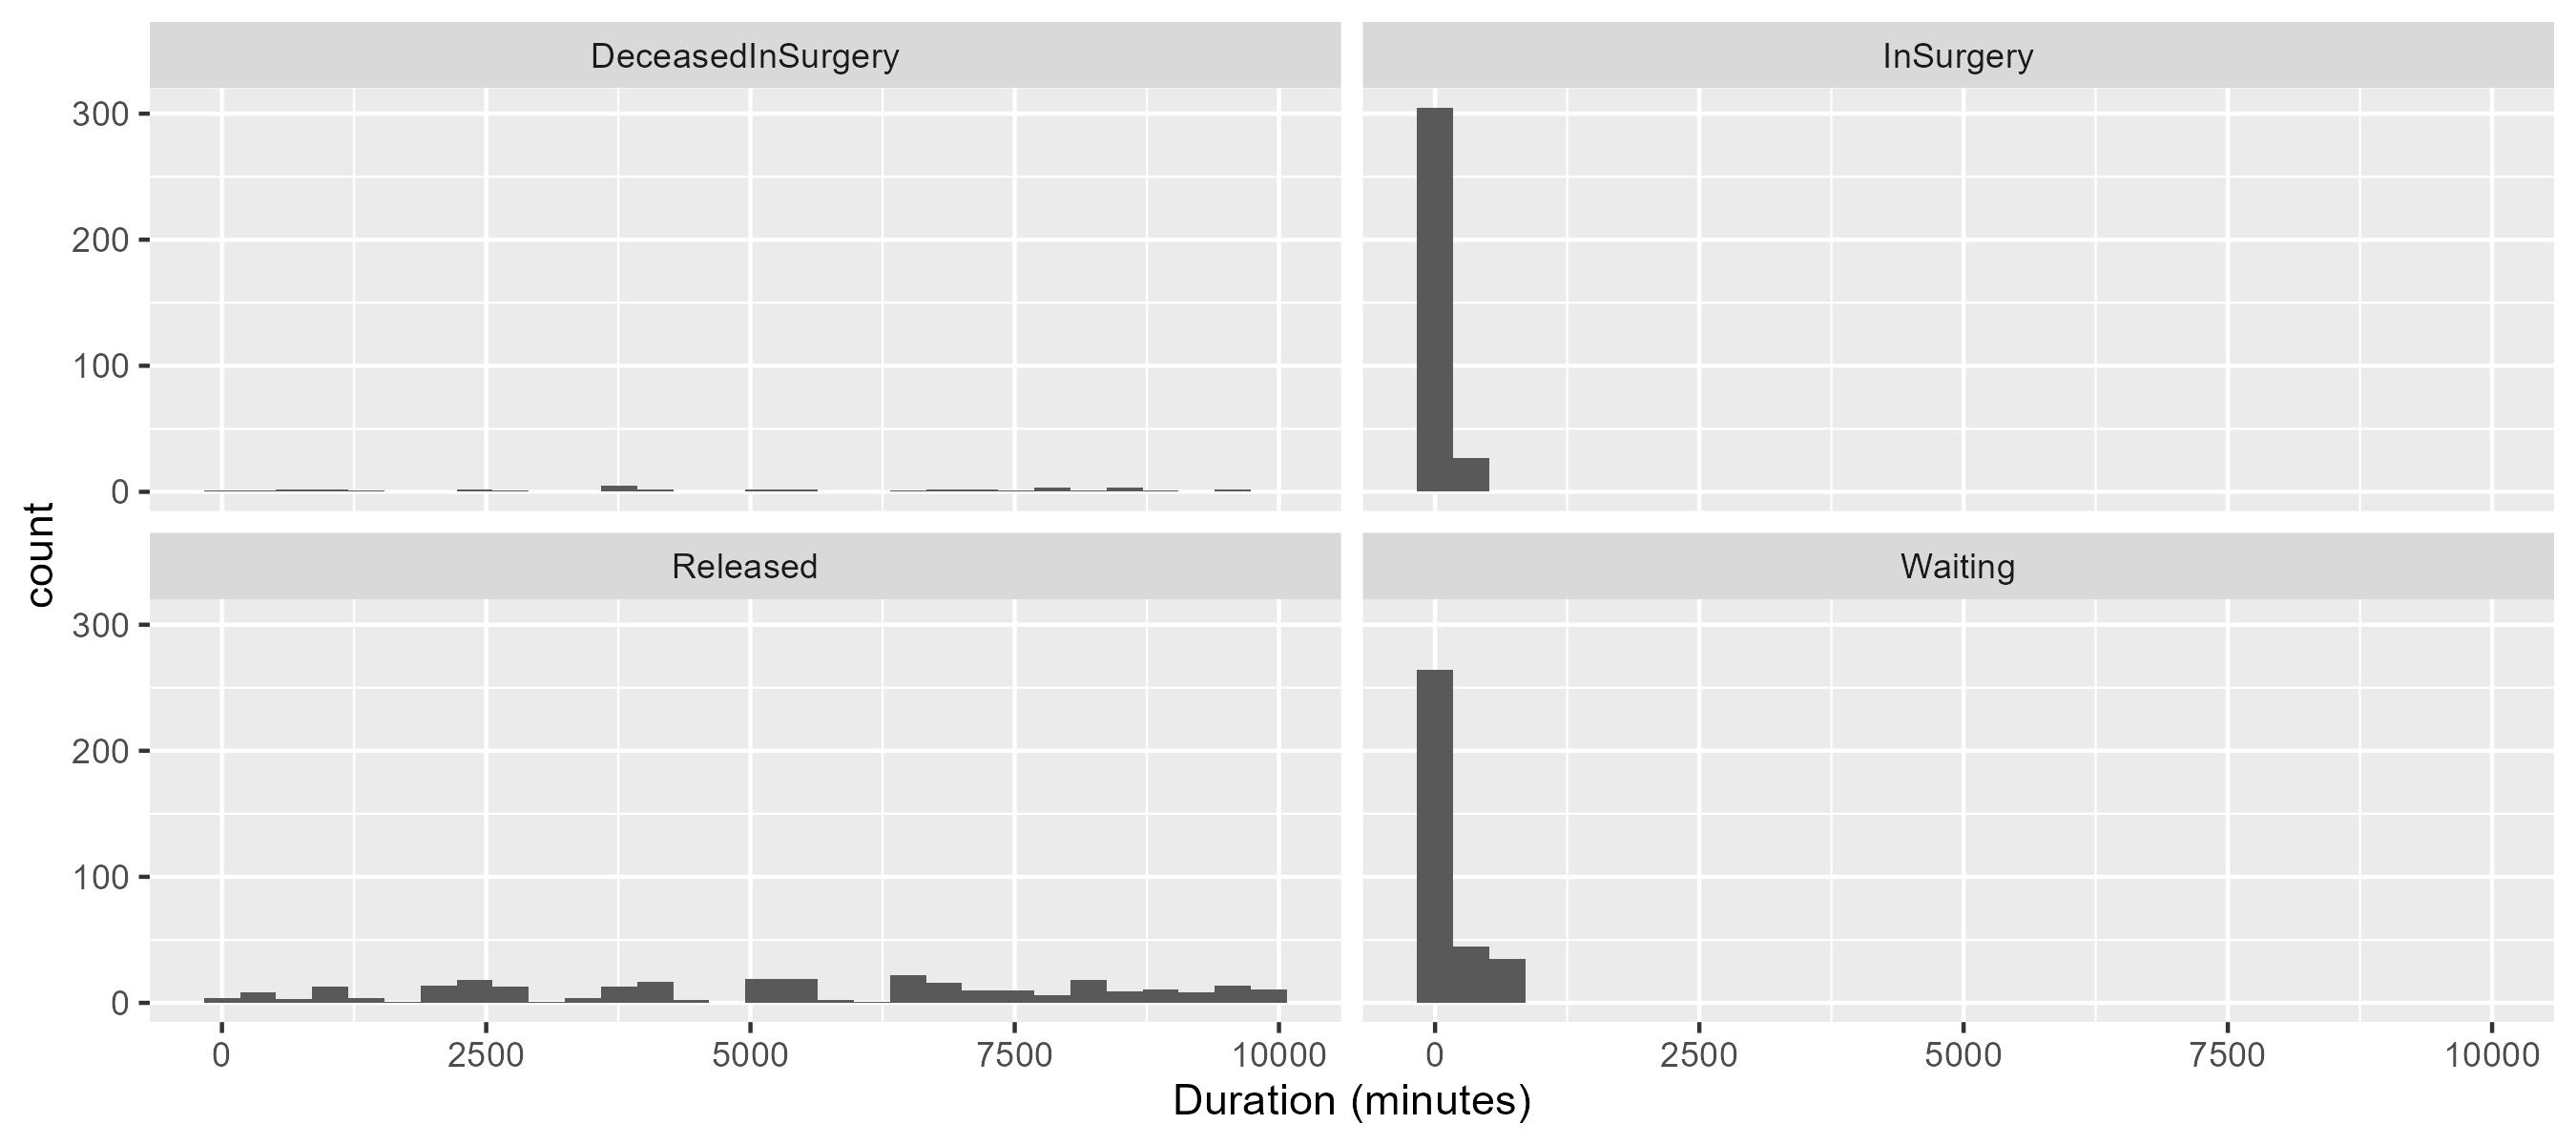

In [16]:
import org.kalasim.plot.kravis.displayStayDistributions

er.patients.map{ it.patientStatus }.displayStayDistributions()


The distribution of stay durations is heavily skewed towards shorter stays, indicating that most patients are discharged quickly. This could be due to the efficient triage and treatment processes in place.


Finally, we inspect raw events from the model (using the [kotlin-dataframe](https://kotlin.github.io/dataframe/quickstart.html) interation)

In [40]:
import org.kalasim.analysis.InteractionEvent

val interactions = er.eventsInstanceOf<InteractionEvent>()

interactions.first()

{"receiver":"main","details":"running; Hold +168.00, scheduled for 168.00","time":"2022-02-23T06:00:00Z","state":"SCHEDULED","type":"RescheduledEvent"}

In [41]:
val intDF = interactions.toDataFrame()

In [48]:
intDF

time,current,component,actionFn,action,eventType,tickTime
2022-02-23T06:00:00Z,null,main,null,"running; Hold +168.00, scheduled for ...",RescheduledEvent,1645596000
2022-02-23T06:00:00Z,room 0,room 0,org.kalasim.analysis.EventsKt$$Lambda...,canceled,ComponentStateChangeEvent,1645596000
2022-02-23T06:00:00Z,room 1,room 1,org.kalasim.analysis.EventsKt$$Lambda...,canceled,ComponentStateChangeEvent,1645596000
2022-02-23T06:00:00Z,room 2,room 2,org.kalasim.analysis.EventsKt$$Lambda...,canceled,ComponentStateChangeEvent,1645596000
2022-02-23T06:00:00Z,room 3,room 3,org.kalasim.analysis.EventsKt$$Lambda...,canceled,ComponentStateChangeEvent,1645596000
2022-02-23T06:00:00Z,ComponentGenerator.1,ComponentGenerator.1,null,"Hold +.08, scheduled for .08",RescheduledEvent,1645596000
2022-02-23T06:04:57.988113230Z,ComponentGenerator.1,"Patient(fullName=Armando Kessler, pat...",null,"Activated, scheduled for .08",RescheduledEvent,1645596297
2022-02-23T06:04:57.988113230Z,ComponentGenerator.1,"Patient(fullName=Armando Kessler, pat...",org.kalasim.analysis.EventsKt$$Lambda...,canceled,ComponentStateChangeEvent,1645596297
2022-02-23T06:04:57.988113230Z,ComponentGenerator.1,ComponentGenerator.1,null,"Hold +.20, scheduled for .28",RescheduledEvent,1645596297
2022-02-23T06:16:54.513625724Z,ComponentGenerator.1,"Patient(fullName=Laurie Keebler, pati...",null,"Activated, scheduled for .28",RescheduledEvent,1645597014


In [55]:
intDF    .groupBy {  expr { eventType } }
    .count()

untitled,count
RescheduledEvent,2547
ComponentStateChangeEvent,860
StateChangedEvent,960
ResourceEvent,1708
InteractionEvent,328


The event distribution shows that the Emergency Room model is primarily time-driven, with RescheduledEvents (~ 40%) dominating due to frequent hold() operations for arrivals, severity escalation, setup, and surgery durations. ResourceEvents (~ 27%) indicate significant doctor allocation and release activity, reflecting contention and queue dynamics around limited medical staff. StateChangedEvents and ComponentStateChangeEvents (~ 28% combined) stem from patient severity progression and status updates (e.g., Waiting → InSurgery → Released/Deceased). InteractionEvents (~ 5%) are comparatively low, suggesting relatively simple direct component interactions. Overall, the model’s dynamics are mainly governed by time scheduling and resource competition rather than complex inter-component messaging.



## Conclusion & Summary

This study demonstrates how a complex and highly dynamic environment such as an Emergency Room can be captured, analyzed, and improved using discrete-event simulation with Kalasim. By explicitly modeling patient deterioration, resource constraints, setup dependencies, and policy-driven decision making, we gain transparency into bottlenecks and systemic trade-offs that are difficult to detect in real operations. The simulation highlights how performance is shaped not only by staffing levels, but by intelligent coordination of rooms, doctors, and triage policies. Such models provide a safe environment to experiment with alternative strategies before applying them in practice. Ultimately, data-driven process modeling enables more informed decisions, more efficient resource utilization, and—most importantly—the potential to save more lives through smarter system design.

Disclaimer: The author is not a medical doctor, so please excuse possible inprecsion in wording and lack of ER process understanding. Feel welcome to suggest corrections or improvements.